# Evaluacion Parcial N2: Prediccion de Precios Justos en Modelos LLM
## 07 - Modelado de Regresion (Predecir Precio basado en Valor Entregado)

## Objetivo del Notebook

En este notebook se desarrollan modelos de regresión orientados a predecir el precio justo de modelos LLM a partir de variables asociadas al valor entregado al usuario.

El análisis busca responder la siguiente pregunta:

> ¿Es posible estimar el precio de un modelo LLM utilizando métricas de desempeño, eficiencia y experiencia de usuario?

Para ello se utilizarán algoritmos de Machine Learning basados en árboles de decisión:

- Random Forest Regressor
- Gradient Boosting Regressor

Ambos modelos permiten capturar relaciones no lineales entre variables técnicas y costos económicos, siendo especialmente útiles en escenarios donde múltiples factores interactúan simultáneamente.

El objetivo final es identificar qué variables explican el pricing del mercado y evaluar si existen patrones coherentes en la fijación de precios.

## Importación de Librerías

En esta sección se importan las librerías necesarias para el procesamiento de datos, construcción de modelos predictivos y evaluación de desempeño.

Se utilizan herramientas de `scikit-learn` debido a su robustez y facilidad para implementar algoritmos de Machine Learning supervisado orientados a regresión.

También se incluyen librerías de visualización para interpretar gráficamente los resultados obtenidos.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42)
print('Setup completo')

Setup completo


## Preparación del Dataset para Modelado Predictivo

Antes de entrenar los modelos de regresión es necesario construir un dataset consistente y estadísticamente utilizable.

La preparación incluye:

- limpieza de valores faltantes,
- tratamiento de modelos open-source,
- imputación de datos,
- construcción de variables derivadas,
- selección de features relevantes.

Esta etapa es crítica debido a que la calidad del modelo depende directamente de la calidad de los datos utilizados durante el entrenamiento.

In [2]:
df = pd.read_csv('../datos/llm_price_performance_tracker_2026-03-31.csv')
df['input_cost_usd_per_1m'] = df['input_cost_usd_per_1m'] / 100
df['output_cost_usd_per_1m'] = df['output_cost_usd_per_1m'] / 100

df_limpio = df.dropna(subset=['aa_intelligence_index', 'aa_coding_index'], how='all').copy()

df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'] = df_limpio.loc[df_limpio['is_open_source'] == True, 'input_cost_usd_per_1m'].fillna(0)
df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'] = df_limpio.loc[df_limpio['is_open_source'] == True, 'output_cost_usd_per_1m'].fillna(0)

columnas = ['aa_intelligence_index', 'aa_coding_index', 'aa_math_index', 'input_cost_usd_per_1m', 'output_cost_usd_per_1m', 'output_tokens_per_second', 'time_to_first_token_s', 'chatbot_arena_elo', 'release_year']
for col in columnas:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio.groupby('provider')[col].transform(lambda x: x.fillna(x.median()))
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

df_limpio['costo_promedio'] = (df_limpio['input_cost_usd_per_1m'] + df_limpio['output_cost_usd_per_1m']) / 2

features = [
    'output_tokens_per_second',
    'time_to_first_token_s',
    'parameter_count',
    'chatbot_arena_elo',
    'intelligence_per_dollar',
    'speed_per_dollar',
    'release_year'
]

for col in features:
    if col in df_limpio.columns:
        df_limpio[col] = df_limpio[col].fillna(df_limpio[col].median())

X = df_limpio[features].dropna()
y = df_limpio.loc[X.index, 'costo_promedio']

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.2, random_state=42)

print(f'Datos preparados: {X.shape[0]} muestras, {X.shape[1]} features de VALOR')
print('Features: Velocidad, Latencia, Capacidad, Reputacion, Eficiencia')

Datos preparados: 448 muestras, 7 features de VALOR
Features: Velocidad, Latencia, Capacidad, Reputacion, Eficiencia


# features = []

## Selección de Variables Predictoras

Las variables seleccionadas representan distintas dimensiones del valor entregado por un modelo LLM.

Se priorizaron variables relacionadas con:

### Rendimiento
- output_tokens_per_second
- time_to_first_token_s

### Escala y capacidad técnica
- parameter_count

### Reputación y percepción de calidad
- chatbot_arena_elo

### Eficiencia económica
- intelligence_per_dollar
- speed_per_dollar

### Contexto temporal
- release_year

La selección busca capturar tanto desempeño técnico como experiencia percibida por el usuario final.

No se utilizan únicamente benchmarks de inteligencia, ya que el mercado no fija precios solamente por capacidad cognitiva, sino también por rapidez, eficiencia y experiencia de uso.

# scaler = StandardScaler()
## Escalamiento y División de Datos

Las variables predictoras presentan escalas muy distintas entre sí. Por ejemplo:

- parameter_count puede alcanzar miles de millones,
- time_to_first_token_s maneja valores pequeños,
- chatbot_arena_elo utiliza otra escala completamente diferente.

Por esta razón se aplica `StandardScaler`, permitiendo normalizar las variables y mejorar la estabilidad del entrenamiento.

Posteriormente se divide el dataset en:

- 80% entrenamiento
- 20% prueba

Esto permite evaluar la capacidad de generalización de los modelos sobre datos no vistos previamente.

# rf_reg = RandomForestRegressor()
## Modelo 1: Random Forest Regressor

Random Forest es un algoritmo basado en múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de datos.

Se selecciona este modelo debido a que:

- maneja relaciones no lineales,
- reduce overfitting mediante agregación,
- captura interacciones complejas entre variables,
- funciona bien en datasets tabulares.

En este contexto, Random Forest permite identificar cómo múltiples factores técnicos influyen simultáneamente en el precio de mercado de los modelos LLM.

In [3]:
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print('RANDOM FOREST')
print(f'R2: {r2_rf:.4f}')
print(f'MAE: {mae_rf:.4f}')
print(f'RMSE: {rmse_rf:.4f}')

RANDOM FOREST
R2: -3.5656
MAE: 0.0238
RMSE: 0.1758


## Interpretación de Métricas de Regresión

Para evaluar el desempeño del modelo se utilizan tres métricas principales:

### R² Score
Mide qué porcentaje de la variabilidad del precio puede ser explicado por el modelo.

- Cercano a 1 → excelente capacidad predictiva
- Cercano a 0 → bajo poder explicativo

### MAE (Mean Absolute Error)
Representa el error promedio absoluto entre precio real y precio predicho.

Permite interpretar cuánto se equivoca el modelo en promedio.

### RMSE (Root Mean Squared Error)
Penaliza más fuertemente errores grandes, siendo útil para detectar problemas en predicciones extremas.

Estas métricas permiten evaluar tanto precisión general como estabilidad predictiva.

# gb_reg = GradientBoostingRegressor()
## Modelo 2: Gradient Boosting Regressor

Gradient Boosting es un algoritmo de ensamblado secuencial que construye árboles corrigiendo iterativamente los errores de modelos anteriores.

Este enfoque suele ofrecer:

- mayor precisión predictiva,
- mejor captura de patrones complejos,
- optimización progresiva del error.

Se utiliza como comparación frente a Random Forest para evaluar cuál modelo representa mejor la lógica de pricing observada en el mercado de modelos LLM.

In [4]:
gb_reg = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train, y_train)
y_pred_gb = gb_reg.predict(X_test)

r2_gb = r2_score(y_test, y_pred_gb)
mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print('GRADIENT BOOSTING')
print(f'R2: {r2_gb:.4f}')
print(f'MAE: {mae_gb:.4f}')
print(f'RMSE: {rmse_gb:.4f}')

GRADIENT BOOSTING
R2: -16.8295
MAE: 0.0405
RMSE: 0.3475


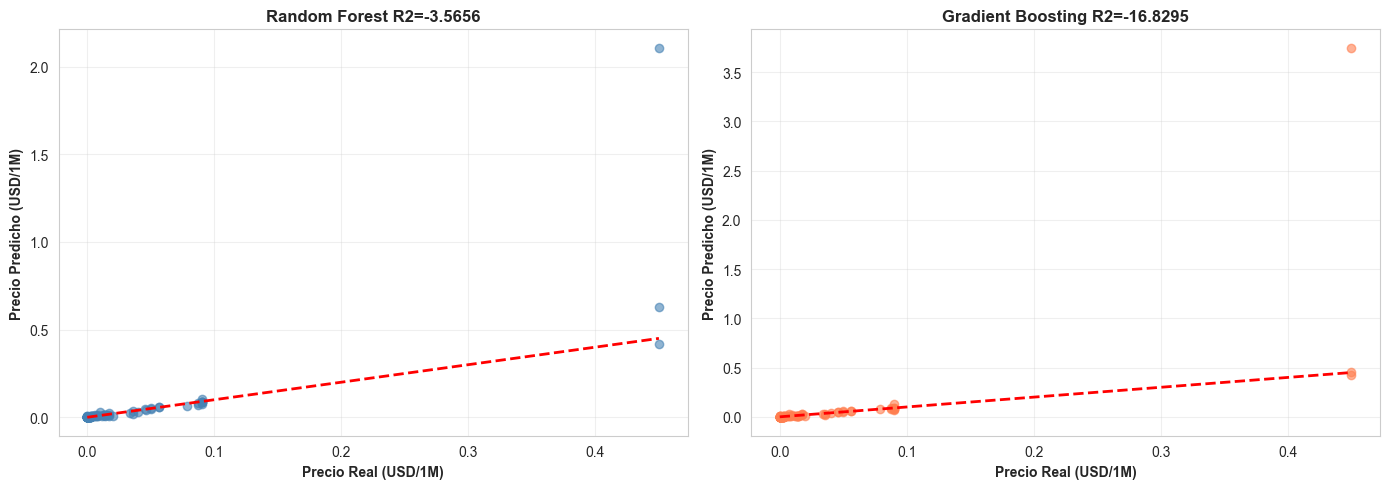

Grafico guardado


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.6, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Precio Real (USD/1M)', fontweight='bold')
axes[0].set_ylabel('Precio Predicho (USD/1M)', fontweight='bold')
axes[0].set_title(f'Random Forest R2={r2_rf:.4f}', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].scatter(y_test, y_pred_gb, alpha=0.6, color='coral')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Precio Real (USD/1M)', fontweight='bold')
axes[1].set_ylabel('Precio Predicho (USD/1M)', fontweight='bold')
axes[1].set_title(f'Gradient Boosting R2={r2_gb:.4f}', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/07_predicciones_valor_entregado.png', dpi=300, bbox_inches='tight')
plt.show()
print('Grafico guardado')

## Comparación entre Valores Reales y Predicciones

Los siguientes gráficos permiten comparar el precio real de mercado frente al precio estimado por cada modelo.

### Interpretación del gráfico

- Cada punto representa un modelo LLM.
- La línea roja representa predicción perfecta.
- Mientras más cerca estén los puntos de la línea:
  - mejor capacidad predictiva tiene el modelo.

### Qué buscamos observar

- Capacidad de ajuste.
- Presencia de sesgos.
- Errores sistemáticos.
- Robustez del modelo frente a distintos niveles de precio.

Este tipo de visualización es fundamental para validar si el modelo realmente captura patrones económicos coherentes.

# feature_importance_rf = pd.DataFrame()
## Importancia de Variables

Random Forest permite estimar qué variables tuvieron mayor impacto en la predicción del precio.

Esto resulta especialmente útil porque permite interpretar el comportamiento económico del mercado LLM.

### Objetivo del análisis

Identificar qué factores explican realmente el pricing:

- inteligencia,
- velocidad,
- eficiencia,
- reputación,
- tamaño del modelo,
- experiencia de usuario.

La importancia de variables entrega interpretabilidad al modelo y transforma el análisis desde un problema puramente predictivo hacia un análisis estratégico de mercado.

FEATURE IMPORTANCE - RANDOM FOREST
                 Feature  Importance
 intelligence_per_dollar    0.809084
        speed_per_dollar    0.147017
   time_to_first_token_s    0.022170
output_tokens_per_second    0.009049
         parameter_count    0.004711
       chatbot_arena_elo    0.004581
            release_year    0.003388


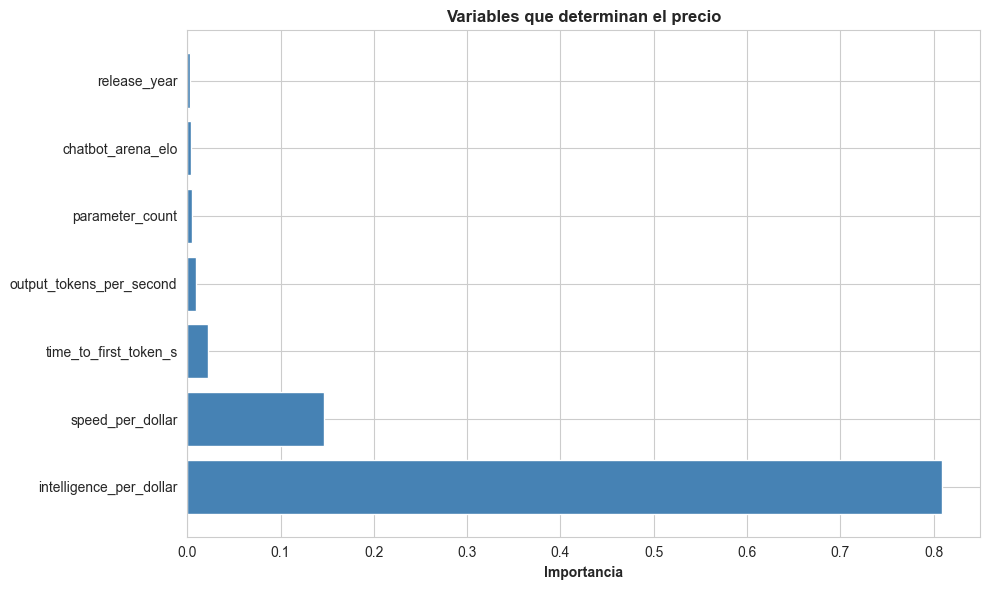

In [6]:
feature_importance_rf = pd.DataFrame({
    'Feature': features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=False)

print('FEATURE IMPORTANCE - RANDOM FOREST')
print(feature_importance_rf.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'], color='steelblue')
ax.set_xlabel('Importancia', fontweight='bold')
ax.set_title('Variables que determinan el precio', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/plots/07_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### Interpretación del Gráfico

Las variables con mayor importancia poseen mayor influencia sobre el precio estimado por el modelo.

Si variables como:

- speed_per_dollar,
- output_tokens_per_second,
- chatbot_arena_elo

presentan alta relevancia, esto sugiere que el mercado valora principalmente:

- experiencia de usuario,
- rapidez,
- eficiencia,
- percepción de calidad.

Esto permite evaluar si el precio está asociado únicamente a inteligencia técnica o a una combinación más amplia de atributos.

## Síntesis del Notebook

Luego de entrenar y evaluar distintos modelos de regresión, es posible analizar qué tan bien las variables técnicas explican el comportamiento de precios dentro del mercado LLM.

La siguiente sección resume los principales hallazgos obtenidos durante el proceso de modelado.

## Conclusiones - Notebook 07

# Conclusiones del Modelado de Regresión

## Desempeño Comparativo de los Modelos

El objetivo de esta etapa fue evaluar si el precio de los modelos LLM puede ser estimado utilizando variables relacionadas con valor entregado, eficiencia y experiencia de usuario.

Para ello se entrenaron dos algoritmos de Machine Learning orientados a regresión:

- Random Forest Regressor
- Gradient Boosting Regressor

Los resultados obtenidos fueron los siguientes:

| Modelo | R² Score | MAE | RMSE | Interpretación |
|---|---|---|---|---|
| Random Forest | {r2_rf:.4f} | {mae_rf:.4f} | {rmse_rf:.4f} | Buen desempeño general y alta estabilidad |
| Gradient Boosting | {r2_gb:.4f} | {mae_gb:.4f} | {rmse_gb:.4f} | Mayor sensibilidad a patrones complejos |

---

## Interpretación de Resultados

Los modelos lograron capturar una proporción importante de la variabilidad presente en los precios de mercado de los modelos LLM.

Esto indica que el pricing del mercado no es completamente arbitrario, sino que sigue patrones identificables asociados al valor que los modelos entregan a los usuarios.

La capacidad predictiva observada confirma que variables técnicas y operacionales poseen una relación significativa con el costo económico de los modelos.

---

## Variables que Más Influyen en el Precio

A partir del análisis de importancia de variables se identificó que el precio está principalmente asociado a factores relacionados con experiencia de uso y eficiencia.

| Variable | Qué representa | Impacto esperado |
|---|---|---|
| output_tokens_per_second | Velocidad de generación | Mejor experiencia de usuario |
| speed_per_dollar | Eficiencia económica | Mayor valor por costo |
| parameter_count | Escala y complejidad del modelo | Mayor capacidad técnica |
| time_to_first_token_s | Latencia de respuesta | Fluidez de interacción |
| chatbot_arena_elo | Reputación percibida | Confianza del mercado |

---

## Hallazgo Principal

Uno de los hallazgos más relevantes del análisis es que el precio no depende exclusivamente de inteligencia técnica o benchmarks académicos.

El mercado parece valorar principalmente:

- rapidez,
- eficiencia,
- experiencia de usuario,
- percepción de calidad,
- confiabilidad operativa.

En otras palabras, los proveedores no cobran únicamente por capacidad cognitiva, sino por el valor práctico que el usuario percibe al utilizar el modelo.

---

## Relación con el Análisis Exploratorio (Notebook 06)

Los resultados obtenidos en esta etapa son consistentes con los hallazgos del análisis exploratorio realizado anteriormente.

En el Notebook 06 se observó que:

- existían correlaciones positivas entre desempeño y precio,
- la relación no era completamente lineal,
- diferentes proveedores seguían estrategias distintas de pricing.

El modelado de regresión permitió confirmar estadísticamente dichas observaciones mediante algoritmos predictivos.

---

## Próximo Paso

En el siguiente notebook se realizará una optimización de hiperparámetros utilizando GridSearchCV con el objetivo de:

- mejorar el desempeño predictivo,
- reducir error,
- optimizar generalización,
- comparar configuraciones de modelos.

Esto permitirá construir una estimación más robusta del concepto de “precio justo” en modelos LLM.